In [54]:
root = "C:/Users/v-wangwilli/projects/nepas"
setwd(root)
.libPaths(file.path(root, "renv/library/windows/R-4.4/x86_64-w64-mingw32"))

library(fixest)
library(tidyverse)

source("script/processors.R")

options(repr.plot.width = 12, repr.plot.height = 8, repr.plot.res = 300)

In [161]:
bps = read_csv("data/cleaned_ocr/bps_final.csv")
bps_13balanced = bps |>
  filter(.by = smsa, n() == 13) |>
  mutate(
    adoption_year = if_else(adoption_year > 1979, Inf, adoption_year)
  )
bps_12 = bps |>
  filter(.by = smsa, n() >= 12)

Rows: 3204 Columns: 22
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): smsa, states, primary_state
dbl (19): year, total_units, private_total, private_1_unit, private_2_units,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [165]:
fepois(
  private_total ~ sunab(adoption_year, year) | smsa + year,
  data = bps_13balanced,
  cluster = ~ primary_state
) |> summary()

Warning message:
"The VCOV matrix is not positive semi-definite and was 'fixed' (see ?vcov)."


Poisson estimation, Dep. Var.: private_total
Observations: 1,287
Fixed-effects: smsa: 99,  year: 13
Standard-errors: Clustered (primary_state) 
           Estimate Std. Error   t value   Pr(>|t|)    
year::-10  0.273367   0.227558  1.201306 2.2963e-01    
year::-9   0.227139   0.272318  0.834097 4.0423e-01    
year::-8   0.197766   0.095188  2.077645 3.7742e-02 *  
year::-7   0.102274   0.101316  1.009449 3.1276e-01    
year::-6   0.105095   0.111519  0.942395 3.4599e-01    
year::-5   0.043900   0.086669  0.506522 6.1249e-01    
year::-4   0.135929   0.093716  1.450430 1.4694e-01    
year::-3  -0.038709   0.065411 -0.591775 5.5400e-01    
year::-2  -0.063625   0.037369 -1.702610 8.8641e-02 .  
year::0   -0.000609   0.026724 -0.022795 9.8181e-01    
year::1   -0.176808   0.040737 -4.340200 1.4235e-05 ***
year::2   -0.151764   0.048619 -3.121458 1.7996e-03 ** 
year::3   -0.123878   0.041237 -3.004047 2.6641e-03 ** 
year::4   -0.092287   0.071196 -1.296241 1.9489e-01    
year::5    0.052

Warning message:
"The VCOV matrix is not positive semi-definite and was 'fixed' (see ?vcov)."


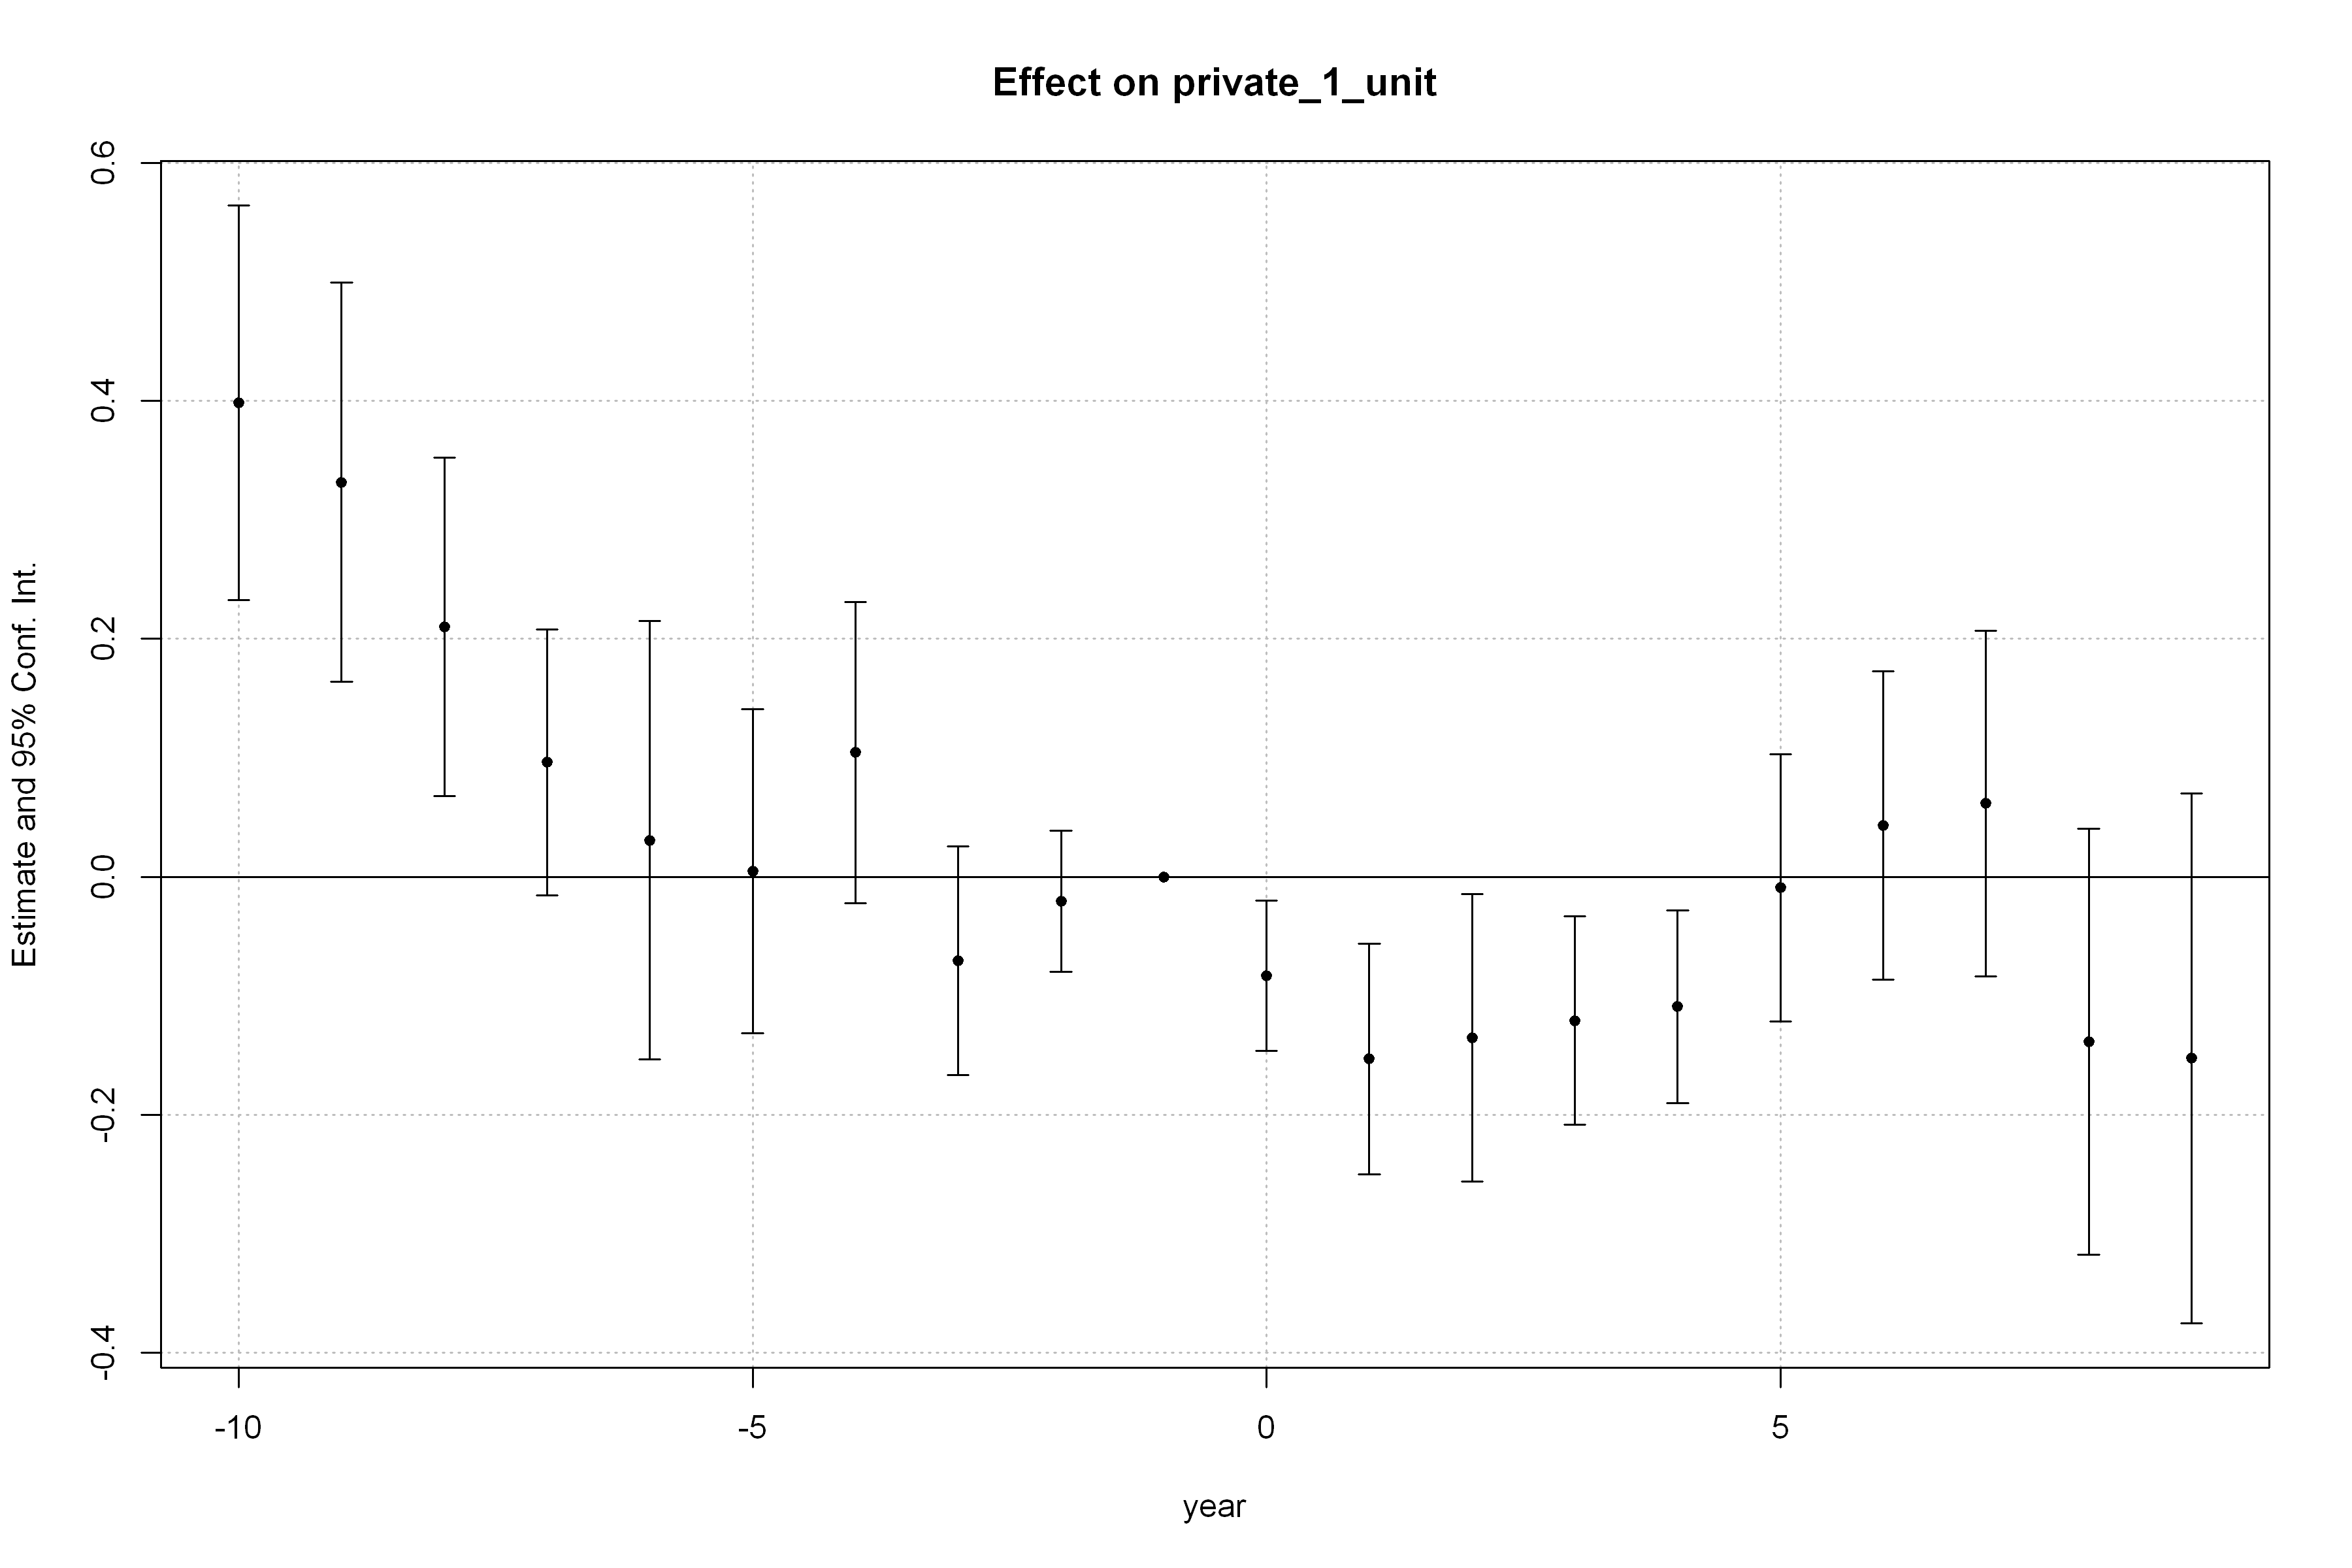

In [ ]:
fepois(
  private_1_unit ~ sunab(adoption_year, year) | smsa + year,
  data = bps_13balanced,
  cluster = ~ primary_state
) |> iplot()

Warning message:
"The VCOV matrix is not positive semi-definite and was 'fixed' (see ?vcov)."


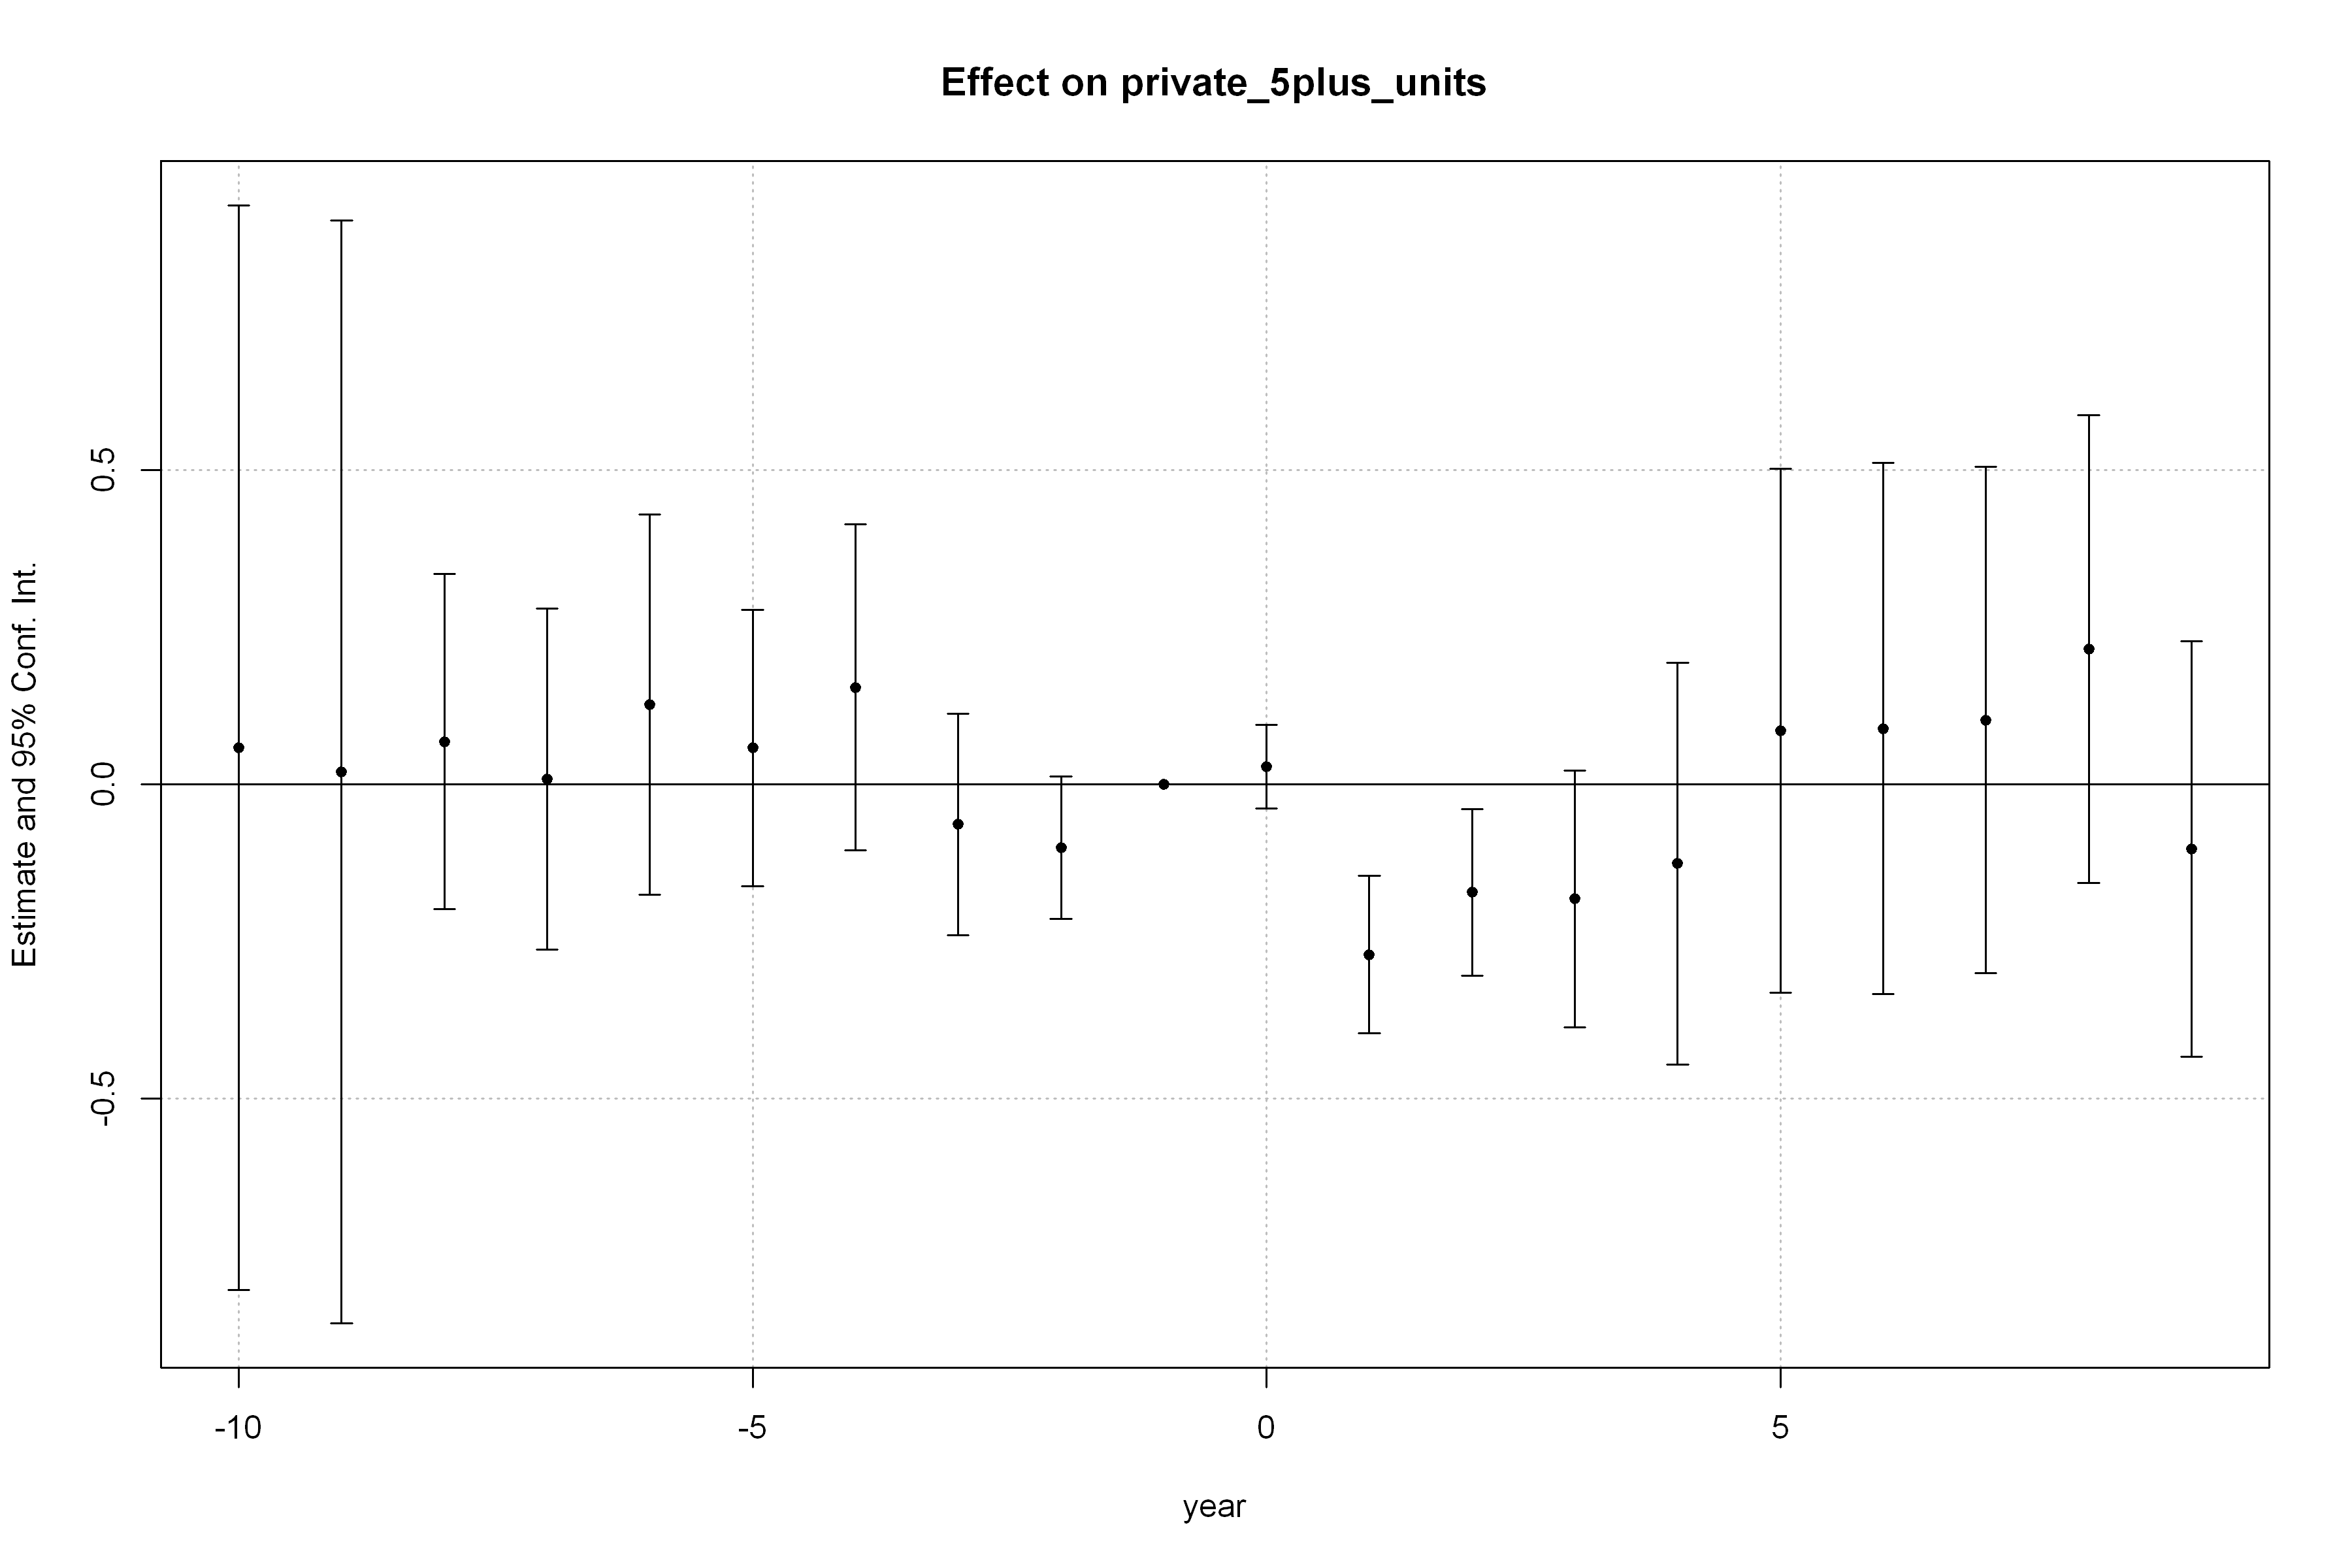

In [154]:
fepois(
  private_5plus_units ~ sunab(adoption_year, year) | smsa + year,
  data = bps_13balanced,
  cluster = ~ primary_state
) |> iplot()

In [60]:
fepois(
  private_total ~ sunab(adoption_year, year) | smsa + year,
  data = bps_12balanced,
  cluster = ~ primary_state
)

Warning message:
"The VCOV matrix is not positive semi-definite and was 'fixed' (see ?vcov)."


Poisson estimation, Dep. Var.: private_total
Observations: 2,727
Fixed-effects: smsa: 219,  year: 13
Standard-errors: Clustered (primary_state) 
          Estimate Std. Error  t value  Pr(>|t|)    
year::-10 0.359775   0.161419 2.228827 0.0258254 *  
year::-9  0.365393   0.198443 1.841299 0.0655778 .  
year::-8  0.313312   0.102796 3.047907 0.0023044 ** 
year::-7  0.107327   0.083901 1.279217 0.2008205    
year::-6  0.196688   0.092784 2.119847 0.0340190 *  
year::-5  0.099239   0.066925 1.482826 0.1381208    
year::-4  0.161916   0.077994 2.076006 0.0378934 *  
year::-3  0.046983   0.065148 0.721180 0.4707988    
... 11 coefficients remaining (display them with summary() or use
argument n)
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Log-Likelihood:  -552,216.5   Adj. Pseudo R2: 0.94921 
           BIC: 1,106,924.9     Squared Cor.: 0.918195

In [22]:
fepois(
  private_total ~ treat | smsa + year,
  data = bps_12balanced,
  cluster = ~ primary_state
)

Poisson estimation, Dep. Var.: private_total
Observations: 2,727
Fixed-effects: smsa: 219,  year: 13
Standard-errors: Clustered (primary_state) 
       Estimate Std. Error  z value Pr(>|z|) 
treat -0.120808   0.092172 -1.31067  0.18997 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Log-Likelihood:  -638,671.3   Adj. Pseudo R2: 0.94127 
           BIC: 1,279,177.9     Squared Cor.: 0.902336

In [ ]:
design_matrix = bps_13balanced |>
  select(private_total, primary_state, year, adoption_year) |>
  bind_cols(
    model.matrix(~ i(adoption_year) + i(year, ref = 1967), data = bps_13balanced)
  ) |>
    rename_with(
    \(col_names) case_when(
      str_detect(col_names, "adoption_year") ~ str_c("adoption_year_", str_extract(col_names, "[0-9]+")) |> replace_na("adoption_year_NA"),
      str_detect(col_names, "ref = 1967") ~ str_c("year_", str_extract(col_names, "[0-9]+$")) |> replace_na("year_NA"),
      .default = col_names
    ),
    .cols = everything()
  )

adoption_years = bps_13balanced |>
  distinct(adoption_year) |>
  pull()

design_matrix

for (adoption_year in adoption_years) {
  
  model.matrix(
    str_glue("~ i(adoption_year})")
  )
}

private_total,primary_state,(Intercept),adoption_year:1970,adoption_year:1971,adoption_year:1972,adoption_year:1973,adoption_year:1974,adoption_year:1975,adoption_year:1977,⋯,year:1970,year:1971,year:1972,year:1973,year:1974,year:1975,year:1976,year:1977,year:1978,year:1979
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4732,OH,1,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3309,NY,1,0,0,0,0,0,1,0,⋯,0,0,0,0,0,0,0,0,0,0
1334,NM,1,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3172,PA,1,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
12179,CA,1,1,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2897,MI,1,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
23447,GA,1,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4951,TX,1,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
1717,CA,1,1,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [150]:
bps_design = bps_13balanced |>
  select(private_total, primary_state, treat) |>
  bind_cols(
    model.matrix(
      ~ i(adoption_year, ref = Inf) + i(year, ref = 1967) + i(adoption_year, i.year),
      data = bps_13balanced
    ) |> as_tibble()
  ) |>
  mutate(
    across(contains("adoption_year, i.year"), \(col) col * treat, .names = "treat_{.col}")
  ) |>
  rename_with(
    \(col_names) str_replace(col_names, "i\\(adoption_year, ref = Inf\\)", "adoption_year_"),
    .cols = starts_with("i(adoption_year")
  ) |> 
  rename_with(
    \(col_names) str_replace(col_names, "i\\(year, ref = 1967\\)", "year_"),
    .cols = starts_with("i(year")
  ) |>
  select(!contains(",") | matches("^treat")) |>
  pivot_longer(
    cols = starts_with("treat_"),
    names_to = c("adoption_year", "year"),
    names_pattern = "treat_i\\(adoption_year, i.year\\)(.*):(.*)",
    values_to = "value"
  ) |>
  filter(adoption_year <= year) |>
  pivot_wider(
    names_from = c("adoption_year", "year"),
    names_glue = "treat_adoption{adoption_year}_year{year}",
    values_from = "value"
  )

names(bps_design)

[1] "private_total"               "primary_state"              
 [3] "treat"                       "(Intercept)"                
 [5] "adoption_year_1970"          "adoption_year_1971"         
 [7] "adoption_year_1972"          "adoption_year_1973"         
 [9] "adoption_year_1974"          "adoption_year_1975"         
[11] "adoption_year_1977"          "adoption_year_1989"         
[13] "adoption_year_1991"          "year_1968"                  
[15] "year_1969"                   "year_1970"                  
[17] "year_1971"                   "year_1972"                  
[19] "year_1973"                   "year_1974"                  
[21] "year_1975"                   "year_1976"                  
[23] "year_1977"                   "year_1978"                  
[25] "year_1979"                   "treat_adoption1970_year1970"
[27] "treat_adoption1970_year1971" "treat_adoption1970_year1972"
[29] "treat_adoption1970_year1973" "treat_adoption1970_year1974"
[31] "treat_adoption1970_year1975" "treat_adoption1970_year1976"
[33] "treat_adoption1970_year1977" "treat_adoption1970_year1978"
[35] "treat_adoption1970_year1979" "treat_adoption1971_year1971"
[37] "treat_adoption1971_year1972" "treat_adoption1971_year1973"
[39] "treat_adoption1971_year1974" "treat_adoption1971_year1975"
[41] "treat_adoption1971_year1976" "treat_adoption1971_year1977"
[43] "treat_adoption1971_year1978" "treat_adoption1971_year1979"
[45] "treat_adoption1972_year1972" "treat_adoption1972_year1973"
[47] "treat_adoption1972_year1974" "treat_adoption1972_year1975"
[49] "treat_adoption1972_year1976" "treat_adoption1972_year1977"
[51] "treat_adoption1972_year1978" "treat_adoption1972_year1979"
[53] "treat_adoption1973_year1973" "treat_adoption1973_year1974"
[55] "treat_adoption1973_year1975" "treat_adoption1973_year1976"
[57] "treat_adoption1973_year1977" "treat_adoption1973_year1978"
[59] "treat_adoption1973_year1979" "treat_adoption1974_year1974"
[61] "treat_adoption1974_year1975" "treat_adoption1974_year1976"
[63] "treat_adoption1974_year1977" "treat_adoption1974_year1978"
[65] "treat_adoption1974_year1979" "treat_adoption1975_year1975"
[67] "treat_adoption1975_year1976" "treat_adoption1975_year1977"
[69] "treat_adoption1975_year1978" "treat_adoption1975_year1979"
[71] "treat_adoption1977_year1977" "treat_adoption1977_year1978"
[73] "treat_adoption1977_year1979"

In [151]:
fepois(
  private_total ~ regex("adoption_year") + regex("year") + regex("treat_adoption"),
  data = bps_design,
  cluster = "primary_state"
) |> summary()

Warning message:
"The VCOV matrix is not positive semi-definite and was 'fixed' (see ?vcov)."


Poisson estimation, Dep. Var.: private_total
Observations: 1,287
Standard-errors: Clustered (primary_state) 
                             Estimate Std. Error   z value   Pr(>|z|)    
(Intercept)                  8.991653   0.138720 64.818641  < 2.2e-16 ***
adoption_year_1970           0.157224   0.142257  1.105209 2.6907e-01    
adoption_year_1971          -0.002970   0.265337 -0.011194 9.9107e-01    
adoption_year_1972          -0.066778   0.253697 -0.263218 7.9238e-01    
adoption_year_1973          -0.210698   0.425240 -0.495480 6.2026e-01    
adoption_year_1974          -0.146516   0.153139 -0.956751 3.3869e-01    
adoption_year_1975           0.197105   0.152341  1.293841 1.9572e-01    
adoption_year_1977          -0.080632   0.348372 -0.231453 8.1696e-01    
adoption_year_1989          -0.263217   0.521006 -0.505208 6.1341e-01    
adoption_year_1991          -0.026224   0.369690 -0.070934 9.4345e-01    
year_1968                    0.195480   0.044507  4.392152 1.1223e-05 ***
yea

In [85]:
fepois(
  private_total ~ i(adoption_year, ref = Inf) + i(year, ref = 1967) + i(year, i.adoption_year),
  data = bps_13balanced,
  cluster = ~ primary_state 
)

The variables 'year::1968:adoption_year::Inf', 'year::1969:adoption_year::Inf',
'year::1970:adoption_year::Inf', 'year::1971:adoption_year::Inf',
'year::1972:adoption_year::Inf', 'year::1973:adoption_year::Inf' and 13 others
have been removed because of collinearity (see $collin.var).

Warning message:
"Absence of convergence: Maximum number of iterations reached (25). Final deviance: 10,542,637.7."
Warning message:
"The VCOV matrix is not positive semi-definite and was 'fixed' (see ?vcov)."
Warning message:
"feglm: Step halving due to non-finite deviance (once)."


Poisson estimation, Dep. Var.: private_total
Observations: 1,287
Standard-errors: Clustered (primary_state) 
                     Estimate Std. Error    z value   Pr(>|z|)    
(Intercept)          2.505859   0.018913 132.493392  < 2.2e-16 ***
adoption_year::1970  5.705078   0.764379   7.463681 8.4138e-14 ***
adoption_year::1971 -4.625000   0.328561 -14.076530  < 2.2e-16 ***
adoption_year::1972 -0.366935   0.367633  -0.998100 3.1823e-01    
adoption_year::1973  0.398636   0.277396   1.437068 1.5070e-01    
adoption_year::1974 -0.672238   0.424241  -1.584566 1.1306e-01    
adoption_year::1975 -0.586180   0.424241  -1.381716 1.6706e-01    
adoption_year::1977 -0.462885   0.369593  -1.252420 2.1042e-01    
... 124 coefficients remaining (display them with summary() or use
argument n)
... 19 variables were removed because of collinearity
(year::1968:adoption_year::Inf, year::1969:adoption_year::Inf and 17
others [full set in $collin.var])
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05

In [ ]:
fepois(
  private_total ~ 
)